In [1]:
import os
import jax

from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots


# import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 250
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

/Users/mc/miniconda3/envs/ami/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [4]:
import jax.numpy as np

outs = np.load(
    "/Users/mc/data/nt_outputs/IO/5672004visibilities.npy", allow_pickle=True
).item()

In [5]:
outs.keys()

dict_keys(['n_basis', '01373_023_02_03_1', '01373_017_02_04_1', '01373_017_02_04_2', '01373_017_02_04_3', '01373_017_02_04_4', '01373_017_02_04_5'])

In [2]:
from astropy.io import fits
from jax import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
import dorito

In [3]:
hdus = fits.open(
    "/Users/mc/Downloads/MAST_2025-09-29T17_29_54.485Z/MAST_2025-09-29T17_29_54.485Z/HST/x24e0106t_c0f.fits"
)

In [4]:
def get_dist(params_path, filt, norm=True, get_fluxes=False):
    params = np.load(params_path, allow_pickle=True).item()
    # print(params["log_dist"].keys())
    dist = 10 ** params["log_dist"][filt]
    if norm:
        dist /= dist.max()
    if get_fluxes:
        # print("Flux:", params["fluxes"].keys())
        return dist, params["fluxes"]
    return dist


best_images = {}

In [5]:
save_path = "/Users/mc/data/nt_outputs/NGC1068/5170358/"
# save_path = "/Users/mc/data/nt_outputs/NGC1068/5169788/"


def get_f(f_list):
    assert len(f_list) == 20

    fs = list(f_list.values())[:5] + list(f_list.values())[10:15]
    return 10 ** np.array(fs).mean()


diff = 13
r, rf = get_dist(f"{save_path}/{diff+0}/params.npy", "F480M", get_fluxes=True)
rf = get_f(rf)
g, gf = get_dist(f"{save_path}/{diff+20}/params.npy", "F430M", get_fluxes=True)
gf = get_f(gf)
b, bf = get_dist(f"{save_path}/{diff+40}/params.npy", "F380M", get_fluxes=True)
bf = get_f(bf)

scale = np.array([rf, gf, bf]).max()
r /= scale
g /= scale
b /= scale

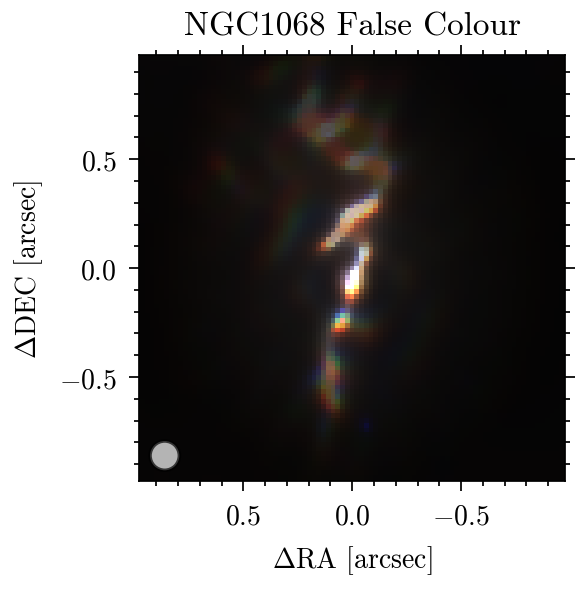

In [36]:
from scipy.ndimage import gaussian_filter
import dLux.utils as dlu

# pixel_scale = model.psf_pixel_scale / model.oversample
pixel_scale = 0.065524085  # arcsec / pixel
diameter = 6.603464  # meters

# r, g, b = [
#     result_model.get_distribution(exp, rotate=False)
#     * (10 ** result_model.params["fluxes"][exp.get_key("fluxes")])
#     for exp in fits
#     if not exp.calibrator
# ]
# # * result_model.params["fluxes"][exp.get_key("fluxes")]

# # r = (
# #     result_model.get_distribution(fits[0], rotate=False)
# #     * result_model.params["fluxes"][fits[0]]
# # )
# # g = result_model.get_distribution(fits[1], rotate=False)
# # b = result_model.get_distribution(fits[2], rotate=False)

# eff_wavel = np.array(
#     [np.dot(*model.filters[exp.filter]) for exp in fits if exp.calibrator is False]
# ).mean()


def blur(factor, arr, wavelength):

    # wavelength in metres
    # wavel = np.dot(*model.filters[filter])
    wavel = wavelength

    # FWHM in pixels
    lambda_over_d = dlu.rad2arcsec(wavel / diameter)  # arcseconds
    lambda_over_d /= pixel_scale  # pixels
    fwhm = factor * lambda_over_d
    sigma = float(fwhm / (2 * (2 * np.log(2)) ** 0.5))

    return gaussian_filter(arr, sigma=(sigma))


# fac = 0.8  # factor to scale the FWHM
# r = blur(fac, r, 4.8e-6)
# g = blur(fac, g, 4.3e-6)
# b = blur(fac, b, 3.8e-6)

power = 0.4
clipped = 0.25

piccy = np.stack([r, g, b], axis=-1)
piccy /= piccy.max()
piccy = piccy**power  # adjust brightness
piccy = np.clip(piccy, 0, clipped)  # remove negative values
piccy /= piccy.max()

# piccy = np.log10(piccy)
# piccy = np.clip(piccy, -4.5, None)
# piccy -= piccy.min()
# piccy /= piccy.max()
# piccy = piccy**0.2

fig, ax = plt.subplots(figsize=(3, 2.5))

c0 = dorito.plotting.plot_result(
    ax,
    piccy,
    pixel_scale=pixel_scale / 3,  # arcseconds/pixel
    scale=1.8,
    # norm=mpl.colors.LogNorm(),
    diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    # ticks=[-0.5, 0, 0.5],
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)


# # Arrow parameters
# arrow_length = 15 * pixel_scale  # in pixels
# origin = -0.95, -0.95  # starting point of arrows (in pixel coords)

# # Draw North arrow
# ax.annotate(
#     "",
#     xy=(origin[0], origin[1] + arrow_length),
#     xytext=origin,
#     arrowprops=dict(
#         facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
#     ),
# )
# ax.text(
#     origin[0],
#     origin[1] + arrow_length + 2 * pixel_scale,
#     "N",
#     color="white",
#     ha="center",
#     va="bottom",
#     fontsize=8,
# )

# # Draw East arrow
# ax.annotate(
#     "",
#     xy=(origin[0] + arrow_length, origin[1]),
#     xytext=origin,
#     arrowprops=dict(
#         facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
#     ),
# )
# ax.text(
#     origin[0] + arrow_length + 6 * pixel_scale,
#     origin[1],
#     "E",
#     color="white",
#     ha="left",
#     va="center",
#     fontsize=8,
# )


ax.set(title=f"NGC1068 False Colour")
plt.tight_layout()
# plt.savefig(output_path + "ngc_1068_false_colour.png", dpi=500, bbox_inches="tight")
plt.show()

In [37]:
cone1 = 128 / 119
cone2 = -132 / 56

/var/folders/y1/hp_l_9fn3pn_1jg3tf9_3g4w0000gn/T/ipykernel_54259/1051364984.py:75: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


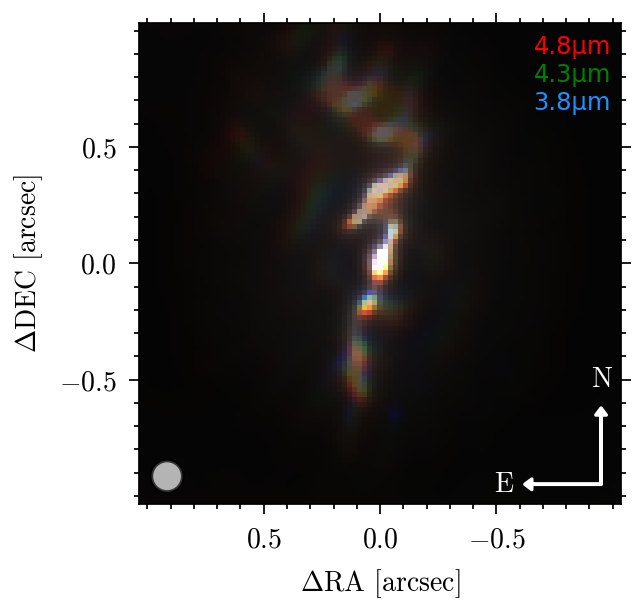

In [38]:
psf_pixel_scale = 0.065524085  # arcsec / pixel

fig, ax = plt.subplots(figsize=(3, 2.5))

c = dorito.plotting.plot_result(
    ax,
    piccy,
    pixel_scale=pixel_scale / 3,  # arcseconds/pixel
    scale=1.7,
    # norm=mpl.colors.LogNorm(),
    diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    translate=(0.0, 0.07),
    # ticks=[-0.5, 0, 0.5],
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)

smbh = (0.03, -0.1)
# ax.axline(smbh, slope=cone1, color="cyan", linestyle="--", lw=0.5)
# ax.axline(smbh, slope=cone2, color="cyan", linestyle="--", lw=0.5)
# ax.contour(lbti0, , colors="red")


# Arrow parameters
arrow_length = 5 * pixel_scale  # in pixels
origin = -0.95, -0.95  # starting point of arrows (in pixel coords)

# Draw North arrow
ax.annotate(
    "",
    xy=(origin[0], origin[1] + arrow_length),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0],
    origin[1] + arrow_length + 1 * pixel_scale,
    "N",
    color="white",
    ha="center",
    va="bottom",
    fontsize=8,
)

# Draw East arrow
ax.annotate(
    "",
    xy=(origin[0] + arrow_length, origin[1]),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0] + arrow_length + 2 * pixel_scale,
    origin[1],
    "E",
    color="white",
    ha="left",
    va="center",
    fontsize=8,
)

font_dict = {
    "family": "sans-serif",
    # "color": "#FED7BC",
    "size": 7,
    # "weight": "bold",
}
ax.text(-0.66, 0.9, "4.8μm", fontdict=font_dict, color="red")
ax.text(-0.66, 0.78, "4.3μm", fontdict=font_dict, color="green")
ax.text(-0.66, 0.66, "3.8μm", fontdict=font_dict, color="dodgerblue")

ax.legend()
# ax.scatter(*smbh, marker="+", color="cyan", s=20, zorder=10)
# fig.colorbar(c, ax=ax)
plt.show()

In [39]:
from astropy.io import fits
from socket import gethostname

# print(gethostname())
if gethostname() == "glinton":
    path = "/media/morgana1/snert/max/"
    save_path = path + "data/dorito_figs"
elif (
    gethostname() == "maxs-mbp-14.research.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    path = "/Volumes/morgana1/snert/max/"
    save_path = "/Users/mc/data/dorito_figs"
else:
    path = "/fred/oz440/max/"
""
lbti0 = fits.open(
    "/Users/mc/Downloads/Re_ NGC1068 Processed Image (1)/ngc1068_paperversion_rldeconv.fits"
)
# lbti0 = fits.open(path + "data/LBTI/ngc1068_paperversion_rldeconv.fits")
lbti0 = np.array(lbti0[0].data)
lbti0 = np.clip(lbti0, 0)
lbti0 /= lbti0.max()

# lbti1 = fits.open(path + "data/LBTI/NGC1068_deconvolved_rl.fits")
lbti1 = fits.open(
    "/Users/mc/Downloads/Re_ NGC1068 Processed Image (1)/NGC1068_deconvolved_rl.fits"
)
lbti1 = np.array(lbti1[0].data)
lbti1 = np.clip(lbti1, 0)
lbti1 /= lbti1.max()

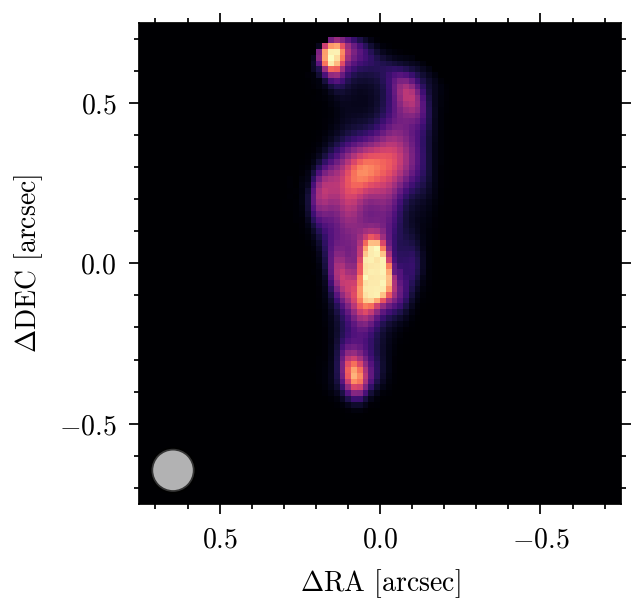

In [40]:
fig, ax = plt.subplots(figsize=(3, 2.5))
c = dorito.plotting.plot_result(
    ax,
    lbti0,
    pixel_scale=18e-3,  # arcseconds/pixel
    scale=1.2,
    cmap="magma",
    norm=mpl.colors.PowerNorm(0.5, vmin=0, vmax=1.0),
    diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    # ticks=[-0.5, 0, 0.5],
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)

In [41]:
def get_arcsec_extents(pixel_scale, shape):
    """
    Get the arcsec extents of an image given the pixel scale and shape.
    """
    return np.array([0.5, -0.5, -0.5, 0.5]) * pixel_scale * shape[0]


from dorito.plotting import get_arcsec_extents


def plot_contour(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = None,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    norm=mpl.colors.PowerNorm(1, vmin=0, vmax=None),
    diff_lim: float = None,
    scale=1.0,
    translate=(0.0, 0.0),
    ticks=[0.5, 0, -0.5],
    **contour_kwargs,
):

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=ticks,
        yticks=ticks[::-1],
        **axis_labels,
    )  # Set the axis labels

    kwargs = {
        "cmap": cmap,
        "extent": get_arcsec_extents(pixel_scale / scale, array.shape),
        "norm": norm,
        "aspect": "equal",
    }

    im = ax.contour(
        array,
        **kwargs,
        **contour_kwargs,
    )

    if diff_lim is not None:

        centre = 0.95 * np.array(kwargs["extent"][0:2]) + np.array(
            [-diff_lim, diff_lim]
        )

        beam = mpl.patches.Circle(
            centre,
            radius=diff_lim,
            facecolor="white",
            edgecolor="black",
            alpha=0.7,
            zorder=10,
        )
        ax.add_patch(beam)

    if roll_angle_degrees is not None or scale is not None:

        if scale is None:
            scale = 1.0
        if roll_angle_degrees is None:
            roll_angle_degrees = 0.0

        rotation_transform = (
            mpl.transforms.Affine2D()
            .rotate_deg(roll_angle_degrees)
            .scale(scale)
            .translate(*translate)
        )  # Create a rotation transformation
        trans_data = rotation_transform + ax.transData  # creating transformation
        im.set_transform(trans_data)  # applying transformation to image

    return im

/var/folders/y1/hp_l_9fn3pn_1jg3tf9_3g4w0000gn/T/ipykernel_54259/679012642.py:45: UserWarning: The following kwargs were not used by contour: 'aspect', 'label'
  im = ax.contour(
/var/folders/y1/hp_l_9fn3pn_1jg3tf9_3g4w0000gn/T/ipykernel_54259/1847606944.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


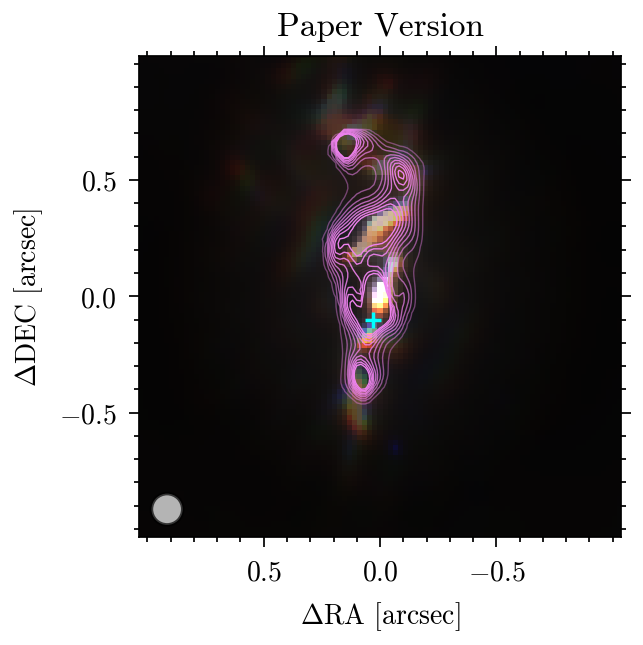

In [75]:
psf_pixel_scale = 0.065524085  # arcsec / pixel

fig, ax = plt.subplots(figsize=(3, 2.5))

c = dorito.plotting.plot_result(
    ax,
    piccy,
    pixel_scale=pixel_scale / 3,  # arcseconds/pixel
    scale=1.7,
    # norm=mpl.colors.LogNorm(),
    diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    translate=(0.0, 0.07),
    # ticks=[-0.5, 0, 0.5],
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)

smbh = (0.03, -0.1)
# ax.axline(smbh, slope=cone1, color="cyan", linestyle="--", lw=0.5)
# ax.axline(smbh, slope=cone2, color="cyan", linestyle="--", lw=0.5)
# ax.contour(lbti0, , colors="red")
c = plot_contour(
    ax,
    lbti0,
    levels=np.linspace(0, clipped**power, 10) ** (1 / power),
    alpha=np.linspace(0, 1.0, 10) ** (power),
    # cmap="spring",
    cmap=None,
    colors="violet",
    pixel_scale=18e-3,  # arcseconds/pixel
    scale=1.7,
    # alpha=0.5,
    # norm=mpl.colors.LogNorm(),
    # diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    linewidths=0.4,
    # linestyles="dashed",
    label="LBTI",
    # ticks=[-0.5, 0, 0.5],
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)
ax.legend()
ax.scatter(*smbh, marker="+", color="cyan", s=20, zorder=10)
# fig.colorbar(c, ax=ax)
plt.title("Paper Version")
plt.show()

/var/folders/y1/hp_l_9fn3pn_1jg3tf9_3g4w0000gn/T/ipykernel_54259/679012642.py:45: UserWarning: The following kwargs were not used by contour: 'aspect', 'label'
  im = ax.contour(
/var/folders/y1/hp_l_9fn3pn_1jg3tf9_3g4w0000gn/T/ipykernel_54259/179111477.py:93: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


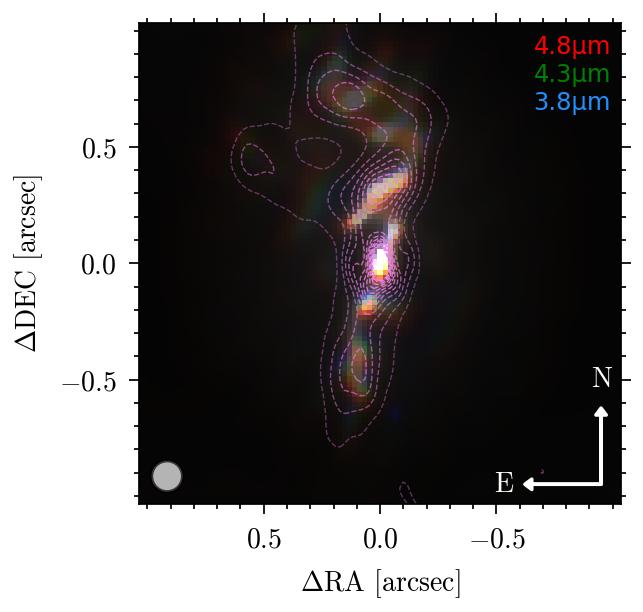

In [77]:
psf_pixel_scale = 0.065524085  # arcsec / pixel

fig, ax = plt.subplots(figsize=(3, 2.5))

c = dorito.plotting.plot_result(
    ax,
    piccy,
    pixel_scale=pixel_scale / 3,  # arcseconds/pixel
    scale=1.7,
    # norm=mpl.colors.LogNorm(),
    diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    translate=(0.0, 0.07),
    # ticks=[-0.5, 0, 0.5],
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)

smbh = (0.03, -0.1)
# ax.axline(smbh, slope=cone1, color="cyan", linestyle="--", lw=0.5)
# ax.axline(smbh, slope=cone2, color="cyan", linestyle="--", lw=0.5)
# ax.contour(lbti0, , colors="red")
c = plot_contour(
    ax,
    lbti1,
    levels=np.linspace(0, clipped**power, 13) ** (1 / power),
    # cmap="spring",
    cmap=None,
    colors="violet",
    pixel_scale=18e-3,  # arcseconds/pixel
    scale=1.7,
    # alpha=0.8,
    alpha=np.linspace(0, 1.0, 13) ** (power),
    # norm=mpl.colors.PowerNorm(0.5),
    # diff_lim=0.5 * dlu.rad2arcsec(4.3e-6 / diameter),
    linewidths=0.4,
    linestyles="dashed",
    label="LBTI",
    # ticks=[-0.5, 0, 0.5],
    # ticks=np.arange(-1, 1.5, 0.5),  # , 0.5, 1.0],
)

# Arrow parameters
arrow_length = 5 * pixel_scale  # in pixels
origin = -0.95, -0.95  # starting point of arrows (in pixel coords)

# Draw North arrow
ax.annotate(
    "",
    xy=(origin[0], origin[1] + arrow_length),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0],
    origin[1] + arrow_length + 1 * pixel_scale,
    "N",
    color="white",
    ha="center",
    va="bottom",
    fontsize=8,
)

# Draw East arrow
ax.annotate(
    "",
    xy=(origin[0] + arrow_length, origin[1]),
    xytext=origin,
    arrowprops=dict(
        facecolor="white", edgecolor="white", width=1e-3, headwidth=3, headlength=2
    ),
)
ax.text(
    origin[0] + arrow_length + 2 * pixel_scale,
    origin[1],
    "E",
    color="white",
    ha="left",
    va="center",
    fontsize=8,
)

font_dict = {
    "family": "sans-serif",
    # "color": "#FED7BC",
    "size": 7,
    # "weight": "bold",
}
ax.text(-0.66, 0.9, "4.8μm", fontdict=font_dict, color="red")
ax.text(-0.66, 0.78, "4.3μm", fontdict=font_dict, color="green")
ax.text(-0.66, 0.66, "3.8μm", fontdict=font_dict, color="dodgerblue")

ax.legend()
# ax.scatter(*smbh, marker="+", color="cyan", s=20, zorder=10)
# fig.colorbar(c, ax=ax)
# plt.title("Updated Version")
plt.savefig("/Users/mc/Downloads/ngc_lbti.pdf", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
disco_path = "/Users/mc/data/nt_outputs/NGC1068/5644707/"

discos = {}
for filt in os.listdir(disco_path):
    disco = np.load(
        os.path.join(disco_path, filt, "discos.npy"), allow_pickle=True
    ).item()
    for key, value in disco.items():
        discos[key] = value
print(discos.keys)

dict_keys(['F480M_24', 'F480M_25', 'F430M_24', 'F430M_25', 'F380M_24', 'F380M_25'])